# Elevation models for `ovgu_bbox` — DGM1, and the road to canopy height

The height model validated in `holdout_validation.ipynb` estimates tree height from **crown area**, and
that notebook put a hard ceiling on the approach: crown diameter is surveyed to the nearest metre, so
trees of the same recorded crown genuinely differ by ~3–4 m in height and no model reading only crown
area can separate them. Out-of-fold MAE was **3.07 m**.

Elevation models sidestep the problem by measuring height instead of inferring it:

| model | what it is | grid | vertical accuracy |
|---|---|---|---|
| **DGM** | bare earth, objects stripped | 1 m | ±15 cm (±30 cm under vegetation) |
| **DOM** | top of everything — canopy, roofs | 1 m | ±50 cm |
| **bDOM** | DOM from photogrammetry, not laser | 20 cm | ±60 cm |
| **nDOM = DOM − DGM** | **height above ground** | — | sum of the two |

`nDOM` over a crown *is* the tree height, directly. This notebook fetches what is programmatically
reachable today and lays out the nDOM computation so it runs the moment a DOM raster is present.

**Service status, checked live.** DGM1 is served as WMS and returns real float32 elevation when asked
for `image/tiff`. The DOM1 WCS (`ST_LVermGeo_DOM1_WCS_OpenData`) returns HTTP 500 on every WCS version
tried, and the DOM1 WMS returns a `ServiceException`. So DGM1 is fetched here; DOM has to come from the
Mapdownloader by hand. Section 5 picks it up automatically once the file exists.

Licence: Datenlizenz Deutschland Namensnennung 2.0 — © GeoBasis-DE / LVermGeo ST.

In [1]:
import io
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rasterio
import requests
from matplotlib.colors import LightSource
from pyproj import Transformer
from rasterio.io import MemoryFile

ROOT = Path.cwd().parent if Path.cwd().name == "test_notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.config import AREAS, OUTPUT_DIR

AREA        = "ovgu_bbox"
UTM         = "EPSG:25832"          # ETRS89 / UTM32N — the CRS every layer in this repo uses
RES_M       = 1.0                   # DGM1 native grid
OUT_DIR     = ROOT / "data" / "terrain"
DGM_PATH    = OUT_DIR / f"{AREA}_dgm1.tif"
DOM_PATH    = OUT_DIR / f"{AREA}_dom1.tif"     # drop a DOM raster here to unlock section 5
OVERWRITE   = False

# LVermGeo Sachsen-Anhalt open-data services. The DOP WMS is the one src/config.py already uses;
# the DGM1 WMS is the same host and the same /wss/service/<name>/guest pattern.
DGM_WMS   = "https://www.geodatenportal.sachsen-anhalt.de/wss/service/ST_LVermGeo_DGM1_WMS_OpenData/guest"
DGM_LAYER = "DGM1"
# A bare requests call is rejected with HTTP 403; the service filters on User-Agent.
HEADERS   = {"User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
                           "AppleWebKit/537.36 (KHTML, like Gecko) Chrome/125.0 Safari/537.36"}

OUT_DIR.mkdir(parents=True, exist_ok=True)

_t = Transformer.from_crs("EPSG:4326", UTM, always_xy=True)
_a = AREAS[AREA]
WEST, SOUTH = _t.transform(_a["west"], _a["south"])
EAST, NORTH = _t.transform(_a["east"], _a["north"])
WIDTH  = int(round((EAST - WEST) / RES_M))
HEIGHT = int(round((NORTH - SOUTH) / RES_M))
print(f"{AREA}: {WEST:.0f},{SOUTH:.0f} -> {EAST:.0f},{NORTH:.0f}  ({UTM})")
print(f"  {EAST-WEST:.0f} x {NORTH-SOUTH:.0f} m  ->  {WIDTH} x {HEIGHT} px at {RES_M} m")

ovgu_bbox: 680650,5779636 -> 681505,5780544  (EPSG:25832)
  855 x 908 m  ->  855 x 908 px at 1.0 m


## 1 · Fetch DGM1

`image/tiff` is the important part of the request. The same service will happily return `image/png`,
but that is a *picture* of the terrain — 8-bit colour, elevation destroyed. Asking for TIFF gets a
single-band float32 GeoTIFF carrying metres above NHN, which is what we can do arithmetic on.

In [2]:
def fetch_elevation(url, layer, path, overwrite=False):
    '''WMS GetMap as float32 GeoTIFF. Returns the local path.'''
    if path.exists() and not overwrite:
        print(f"{path.name} already present ({path.stat().st_size/1e6:.1f} MB) — set OVERWRITE=True to refetch")
        return path
    params = {
        "SERVICE": "WMS", "VERSION": "1.3.0", "REQUEST": "GetMap",
        "LAYERS": layer, "STYLES": "", "CRS": UTM,
        "BBOX": f"{WEST},{SOUTH},{EAST},{NORTH}",
        "WIDTH": WIDTH, "HEIGHT": HEIGHT,
        "FORMAT": "image/tiff",
    }
    r = requests.get(url, params=params, headers=HEADERS, timeout=300)
    r.raise_for_status()
    if r.content[:5] == b"<?xml":          # the service reports failure as XML with HTTP 200
        raise RuntimeError(f"service returned an exception, not a raster:\n{r.text[:400]}")
    with MemoryFile(r.content) as mem, mem.open() as src:
        prof = src.profile | {"driver": "GTiff", "compress": "deflate", "predictor": 3}
        with rasterio.open(path, "w", **prof) as dst:
            dst.write(src.read())
    print(f"saved {path.name}  ({path.stat().st_size/1e6:.1f} MB)")
    return path

fetch_elevation(DGM_WMS, DGM_LAYER, DGM_PATH, OVERWRITE)

with rasterio.open(DGM_PATH) as ds:
    dgm = ds.read(1).astype("float32")
    dgm_transform, dgm_crs = ds.transform, ds.crs
    extent = (ds.bounds.left, ds.bounds.right, ds.bounds.bottom, ds.bounds.top)

valid = np.isfinite(dgm) & (dgm > -1000)
print(f"\n{dgm.shape[1]} x {dgm.shape[0]} px, {dgm.dtype}, CRS {dgm_crs}")
print(f"elevation (m above NHN): min {dgm[valid].min():.2f}  max {dgm[valid].max():.2f}  "
      f"mean {dgm[valid].mean():.2f}  relief {dgm[valid].max()-dgm[valid].min():.2f} m")
print(f"valid pixels: {100*valid.mean():.1f}%")

saved ovgu_bbox_dgm1.tif  (1.6 MB)

855 x 908 px, float32, CRS EPSG:25832
elevation (m above NHN): min 45.50  max 55.11  mean 51.12  relief 9.60 m
valid pixels: 100.0%


## 2 · What the terrain looks like

Three views of the same array. The raw elevation ramp shows how little relief there is — this is the
Elbe valley floor, and a linear colour ramp over ~10 m mostly shows noise. Hillshading is what makes
sub-metre structure legible: it lights the surface from a low sun and renders slope as brightness, so
embankments, ditches and the river terrace appear that a colour ramp flattens out.

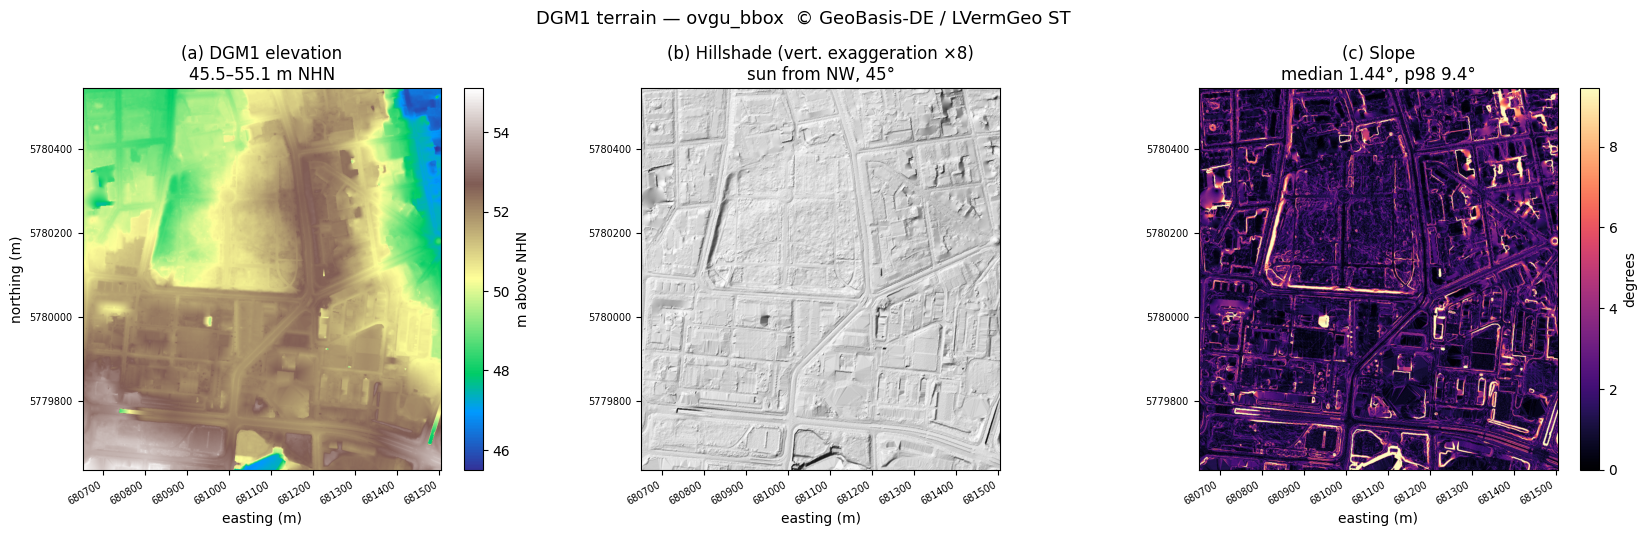

In [3]:
ls = LightSource(azdeg=315, altdeg=45)
dgm_f = np.where(valid, dgm, np.nan)
gy, gx = np.gradient(dgm_f, RES_M)
slope_deg = np.degrees(np.arctan(np.hypot(gx, gy)))

fig, ax = plt.subplots(1, 3, figsize=(17, 5.4))

im = ax[0].imshow(dgm_f, extent=extent, cmap="terrain", origin="upper")
ax[0].set_title(f"(a) DGM1 elevation\n{dgm[valid].min():.1f}–{dgm[valid].max():.1f} m NHN")
fig.colorbar(im, ax=ax[0], fraction=.046, label="m above NHN")

ax[1].imshow(ls.hillshade(np.nan_to_num(dgm_f, nan=np.nanmean(dgm_f)), vert_exag=8,
                          dx=RES_M, dy=RES_M), extent=extent, cmap="gray", origin="upper")
ax[1].set_title("(b) Hillshade (vert. exaggeration ×8)\nsun from NW, 45°")

im = ax[2].imshow(slope_deg, extent=extent, cmap="magma", origin="upper",
                  vmin=0, vmax=np.nanpercentile(slope_deg, 98))
ax[2].set_title(f"(c) Slope\nmedian {np.nanmedian(slope_deg):.2f}°, "
                f"p98 {np.nanpercentile(slope_deg, 98):.1f}°")
fig.colorbar(im, ax=ax[2], fraction=.046, label="degrees")

for a in ax:
    a.set_xlabel("easting (m)"); a.ticklabel_format(style="plain", useOffset=False)
    a.tick_params(labelsize=7); plt.setp(a.get_xticklabels(), rotation=30, ha="right")
ax[0].set_ylabel("northing (m)")
fig.suptitle(f"DGM1 terrain — {AREA}  © GeoBasis-DE / LVermGeo ST", fontsize=13)
fig.tight_layout()
plt.show()

## 3 · Terrain under the trees and buildings

The point of having a DGM in this project is that it is the **subtraction base**: any object height is
that object's surface elevation minus the ground beneath it. So the first sanity check is whether the
ground under the crowns the segmenter found is sensible, and how much of the crown-to-crown height
spread is just the terrain they stand on rather than the trees themselves.

1434 crown polygons, 261 building footprints

ground elevation under crowns: 46.00 – 54.87 m NHN  (spread 8.87 m)
modelled tree heights span 4.0 – 32.4 m

So terrain relief here is comparable to tree height: absolute surface elevation alone
cannot be read as tree height, which is exactly why a DOM needs the DGM subtracted from it.


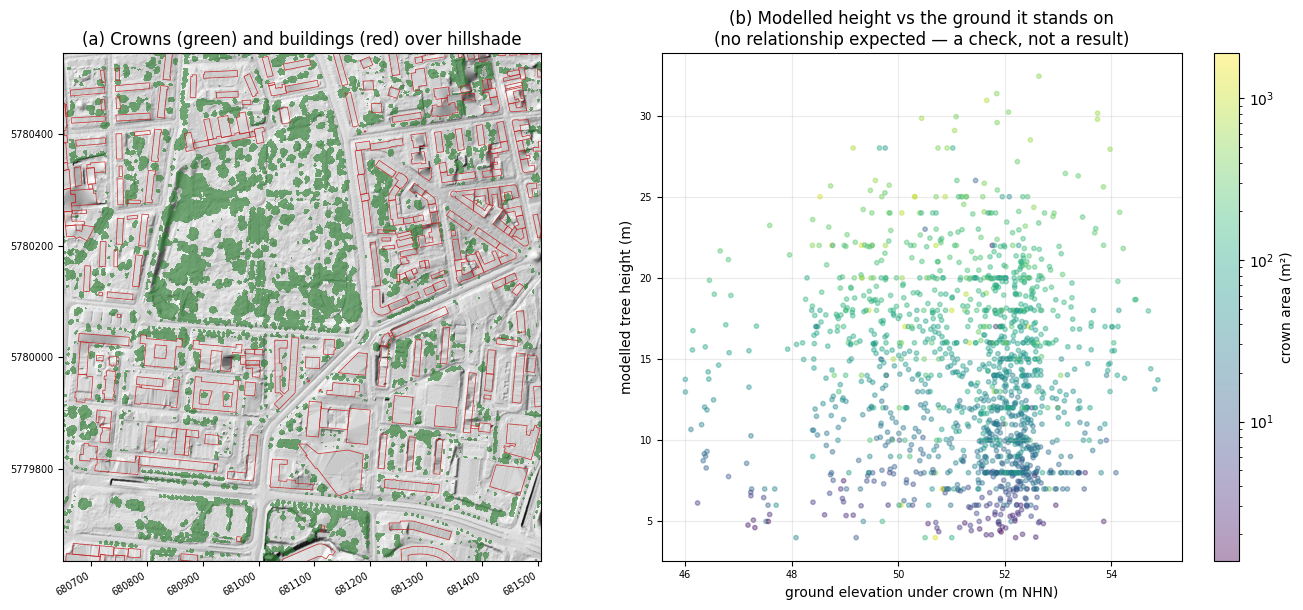

In [4]:
trees_fgb = OUTPUT_DIR / "segments" / "250m" / f"{AREA}_tcd_segformer_trees_merged.fgb"
bldg_fgb  = OUTPUT_DIR / f"buildings_{AREA}.fgb"

trees = gpd.read_file(trees_fgb).to_crs(UTM)
bldgs = gpd.read_file(bldg_fgb).to_crs(UTM) if bldg_fgb.exists() else None
print(f"{len(trees)} crown polygons, {0 if bldgs is None else len(bldgs)} building footprints")

# Ground elevation at each crown centroid, sampled from the DGM.
rows, cols = rasterio.transform.rowcol(dgm_transform, trees.geometry.centroid.x, trees.geometry.centroid.y)
rows, cols = np.clip(rows, 0, dgm.shape[0]-1), np.clip(cols, 0, dgm.shape[1]-1)
trees["ground_m"] = dgm[rows, cols]
ok = np.isfinite(trees["ground_m"]) & (trees["ground_m"] > -1000)
print(f"\nground elevation under crowns: {trees.loc[ok,'ground_m'].min():.2f} – "
      f"{trees.loc[ok,'ground_m'].max():.2f} m NHN  (spread {trees.loc[ok,'ground_m'].max()-trees.loc[ok,'ground_m'].min():.2f} m)")
print(f"modelled tree heights span {trees['height_m'].min():.1f} – {trees['height_m'].max():.1f} m")
print("\nSo terrain relief here is comparable to tree height: absolute surface elevation alone")
print("cannot be read as tree height, which is exactly why a DOM needs the DGM subtracted from it.")

fig, ax = plt.subplots(1, 2, figsize=(14, 6.2))
ax[0].imshow(ls.hillshade(np.nan_to_num(dgm_f, nan=np.nanmean(dgm_f)), vert_exag=8, dx=RES_M, dy=RES_M),
             extent=extent, cmap="gray", origin="upper")
trees.plot(ax=ax[0], facecolor="#2e7d32", edgecolor="none", alpha=.65)
if bldgs is not None:
    bldgs.plot(ax=ax[0], facecolor="none", edgecolor="#c62828", linewidth=.5)
ax[0].set_xlim(extent[0], extent[1]); ax[0].set_ylim(extent[2], extent[3])
ax[0].set_title("(a) Crowns (green) and buildings (red) over hillshade")

sc = ax[1].scatter(trees.loc[ok, "ground_m"], trees.loc[ok, "height_m"],
                   s=10, alpha=.4, c=trees.loc[ok, "crown_area_m2"], cmap="viridis",
                   norm=plt.matplotlib.colors.LogNorm())
fig.colorbar(sc, ax=ax[1], label="crown area (m²)")
ax[1].set(xlabel="ground elevation under crown (m NHN)", ylabel="modelled tree height (m)",
          title="(b) Modelled height vs the ground it stands on\n(no relationship expected — a check, not a result)")
ax[1].grid(alpha=.25)
for a in ax:
    a.ticklabel_format(style="plain", useOffset=False); a.tick_params(labelsize=7)
plt.setp(ax[0].get_xticklabels(), rotation=30, ha="right")
fig.tight_layout()
plt.show()

## 4 · A cross-section

A profile line makes the vertical scale concrete in a way a map cannot. Everything the shadow model
does — `shadow_length = height / tan(sun_elevation)` — happens in this plane.

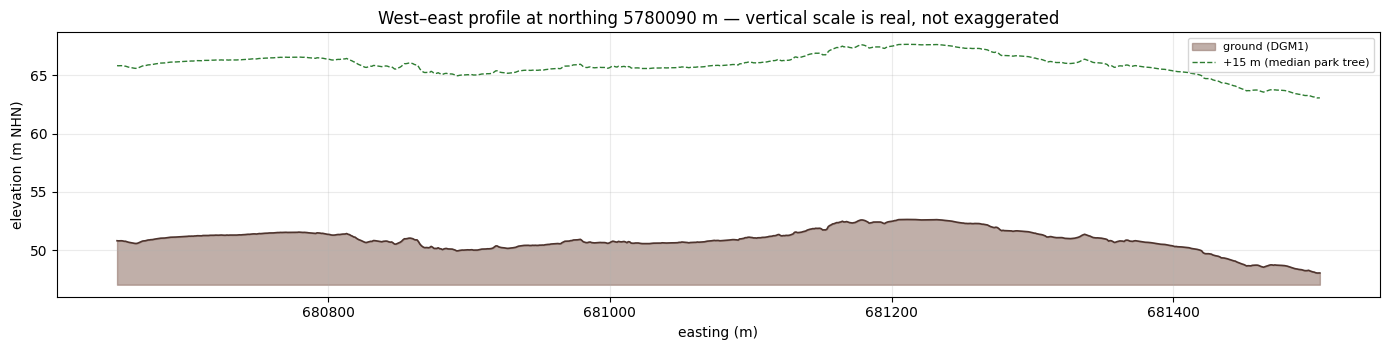

terrain along this line varies by 4.59 m
a median park tree is 15 m — 3.3x the local relief


In [5]:
mid_row = dgm.shape[0] // 2
prof = dgm_f[mid_row, :]
xs = extent[0] + np.arange(len(prof)) * RES_M
northing = extent[3] - mid_row * RES_M

fig, ax = plt.subplots(figsize=(14, 3.6))
ax.fill_between(xs, np.nanmin(prof) - 1, prof, color="#8d6e63", alpha=.55, label="ground (DGM1)")
ax.plot(xs, prof, color="#4e342e", lw=1.2)
# What a 15 m tree (the registry median for this area) would reach, for scale.
ax.plot(xs, prof + 15, color="#2e7d32", lw=1, ls="--", label="+15 m (median park tree)")
ax.set(xlabel="easting (m)", ylabel="elevation (m NHN)",
       title=f"West–east profile at northing {northing:.0f} m — vertical scale is real, not exaggerated")
ax.legend(fontsize=8); ax.grid(alpha=.25)
ax.ticklabel_format(style="plain", useOffset=False)
fig.tight_layout()
plt.show()

print(f"terrain along this line varies by {np.nanmax(prof)-np.nanmin(prof):.2f} m")
print(f"a median park tree is {15.0:.0f} m — {15.0/(np.nanmax(prof)-np.nanmin(prof)):.1f}x the local relief")

## 5 · nDOM — canopy height, once a DOM exists

This is the payoff, and it is three lines of arithmetic:

```
nDOM = DOM − DGM          # height above ground, per pixel
tree_height = nDOM sampled inside each crown polygon, taken as a high percentile
```

A high percentile (p95 rather than the max) is the standard choice — the maximum is a single pixel and
therefore noise-sensitive, while p95 tracks the top of the crown robustly. `validation.ipynb` §6 uses
exactly this convention for its CHM comparison, so staying with it keeps the two comparable.

**Getting a DOM.** The DOM1 WCS is returning HTTP 500, so it has to come from the Mapdownloader by
hand for now: <https://geodatenportal.sachsen-anhalt.de/gfds/de/gdp-dgm1.html> (max 5 tiles at a time,
1 km × 1 km tiles). `ovgu_bbox` spans roughly E 680650–681505, N 5779636–5780544, so it touches the
tiles at 680/5779, 680/5780, 681/5779 and 681/5780. Mosaic them, clip to the bbox, and save to the
`DOM_PATH` set in the fields cell. This section then runs unchanged.

In [6]:
if not DOM_PATH.exists():
    print(f"No DOM raster at {DOM_PATH.relative_to(ROOT)} — section 5 skipped.\n")
    print("The computation this section would run:")
    print("  ndom   = dom - dgm                       # height above ground")
    print("  height = p95 of ndom inside each crown    # per-tree canopy height")
    print("  compare against trees['height_m'] (allometric) and the registry Baumhoehe")
    print("\nExpected impact, from holdout_validation.ipynb:")
    print("  allometric out-of-fold MAE      3.07 m")
    print("  DOM(±0.5 m) - DGM(±0.3 m)       ~0.6 m combined  ->  ~5x better")
else:
    from rasterio.enums import Resampling
    with rasterio.open(DOM_PATH) as ds:
        dom = ds.read(1, out_shape=dgm.shape, resampling=Resampling.bilinear).astype("float32")
    ndom = np.where(valid & np.isfinite(dom), dom - dgm, np.nan)
    ndom = np.where(ndom > -1, ndom, np.nan)          # small negatives are noise in flat ground

    from rasterio.features import geometry_mask
    heights = []
    for geom in trees.geometry:
        m = ~geometry_mask([geom], out_shape=dgm.shape, transform=dgm_transform, invert=False)
        v = ndom[m & np.isfinite(ndom)]
        heights.append(np.percentile(v, 95) if v.size else np.nan)
    trees["ndom_height_m"] = heights

    both = trees[["height_m", "ndom_height_m"]].dropna()
    err = both["height_m"] - both["ndom_height_m"]
    print(f"nDOM range {np.nanmin(ndom):.1f} – {np.nanmax(ndom):.1f} m")
    print(f"crowns measured: {len(both)} of {len(trees)}")
    print(f"allometric vs nDOM:  bias {err.mean():+.2f} m   MAE {err.abs().mean():.2f} m   "
          f"r {both.corr().iloc[0,1]:.3f}")

    fig, ax = plt.subplots(1, 2, figsize=(14, 5.6))
    im = ax[0].imshow(ndom, extent=extent, cmap="YlGn", origin="upper", vmin=0, vmax=25)
    fig.colorbar(im, ax=ax[0], fraction=.046, label="height above ground (m)")
    ax[0].set_title("(a) nDOM = DOM − DGM")
    ax[1].scatter(both["ndom_height_m"], both["height_m"], s=12, alpha=.45, color="#2e7d32")
    lim = [0, max(both.max()) * 1.05]
    ax[1].plot(lim, lim, "k--", lw=1, label="1:1")
    ax[1].set(xlim=lim, ylim=lim, xlabel="nDOM height (measured, m)",
              ylabel="allometric height (modelled, m)", title="(b) Measured vs modelled")
    ax[1].legend(fontsize=8); ax[1].grid(alpha=.25)
    fig.tight_layout()
    plt.show()

No DOM raster at data/terrain/ovgu_bbox_dom1.tif — section 5 skipped.

The computation this section would run:
  ndom   = dom - dgm                       # height above ground
  height = p95 of ndom inside each crown    # per-tree canopy height
  compare against trees['height_m'] (allometric) and the registry Baumhoehe

Expected impact, from holdout_validation.ipynb:
  allometric out-of-fold MAE      3.07 m
  DOM(±0.5 m) - DGM(±0.3 m)       ~0.6 m combined  ->  ~5x better


## What this changes

The DGM is fetched and usable, and the nDOM path is one raster away from running.

Worth being clear about what a DOM would and would not fix. It replaces the **height estimate** —
`ALLOMETRIC_A/B`, the per-genus profiles, and the crown-area-to-height assumption all become
unnecessary, for matched and unmatched crowns alike. That removes the 3.07 m MAE and, more
importantly, removes the dependency on registry species that covers only ~36 % of segmented crowns.

It does **not** fix the shadow geometry. `cast_tree_shadows` sweeps the crown footprint along the sun
azimuth from zero displacement, which assumes canopy from the ground up and yields roughly **2× the
true shaded area** at typical sun angles, while `MAX_SHADOW_FACTOR = 5.0` truncates low-sun shadows to
a fifth of their real length. An exact height feeds a geometry that is wrong in shape regardless.

The nDOM does open the door to fixing that too, though: it carries crown *base* height as well as top,
which is the parameter the sweep is missing.